# Plant Disease Classification

## `mlflow` para controlar os experimentos

In [1]:
import mlflow

mlflow.set_experiment("Plant Disease Classification")

# documentação recomenda
mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

/home/ricardo/anaconda3/envs/plant-disease/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
params = {
    "data_augmentation": True, # se usará TrivialAugment 
    "img_size": 128, 
    "fraction": 0.2, # fração do dataset de treino para acelerar o treino
    "epochs": 20,
    "learning_rate": 1e-4,
    "batch_size": 128,
    "hidden_units": 1024, # número de neurônios no classifier
}

## Manipulando diretórios

In [3]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

In [4]:
from pathlib import Path

base_path = Path(path)

In [5]:
child_paths = list(base_path.iterdir())
train_and_validation_path = child_paths[0]
test_path = child_paths[1]

In [6]:
train_path = train_and_validation_path / "train"
validation_path = train_and_validation_path / "valid"

In [7]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as T

train_transforms=test_transforms=transforms=T.Compose([
        T.Resize(size=(params["img_size"], params["img_size"])),
        T.ToTensor()
    ])

if params["data_augmentation"]:
    train_transforms=T.Compose([
        T.Resize(size=(params["img_size"], params["img_size"])),
        T.TrivialAugmentWide(), #<- 
        T.ToTensor()
    ])

train_dataset = ImageFolder(root=train_path, transform=train_transforms)
validation_dataset = ImageFolder(root=validation_path, transform=test_transforms)

In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

def reduce_dataset(dataset, fraction:float, seed:int=42):
    labels=dataset.targets
    original_indexes=list(range(len(dataset)))
    idxs_reduced, _, _, _ = train_test_split(
        original_indexes,
        labels,
        train_size=fraction,
        stratify=labels,
        random_state=seed
    )

    reduce_dataset = Subset(dataset, idxs_reduced)
    return reduce_dataset

In [9]:
train_dataset = reduce_dataset(train_dataset, fraction=params["fraction"])

## Exibindo informações dos datasets

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def dataset_info(dataset):
    print("[INFO] Tamanho do Dataset:", len(dataset))
    idx=np.random.randint(0, len(dataset)-1)
    img, lbl = dataset[idx]
    print("[INFO] Dimensões da imagem: ", img.shape)
    print("[INFO] Número de classes: ", len(validation_dataset.classes))
    plt.imshow(img.permute(1,2,0))
    plt.title("Classe = {}".format(validation_dataset.classes[lbl]))
    plt.axis(False)
    plt.show()
    plt.close()

[INFO] Tamanho do Dataset: 14059
[INFO] Dimensões da imagem:  torch.Size([3, 128, 128])
[INFO] Número de classes:  38


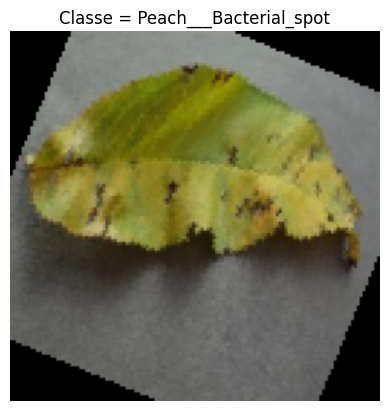

In [11]:
dataset_info(train_dataset)

[INFO] Tamanho do Dataset: 17572
[INFO] Dimensões da imagem:  torch.Size([3, 128, 128])
[INFO] Número de classes:  38


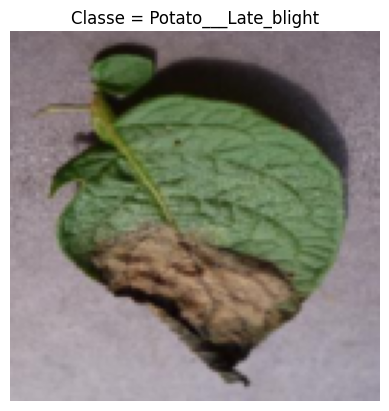

In [12]:
dataset_info(validation_dataset)

## Dataloader

In [13]:
from torch.utils.data import DataLoader
import os

nw = os.cpu_count()
print("[INFO] Usando Num Workers = ", nw)

train_dataloader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=nw, pin_memory=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=nw, pin_memory=True) 

[INFO] Usando Num Workers =  12


## Modelo

In [14]:
from torch import nn

class Classifier(nn.Module):
    def __init__(self, in_channels, hidden_layers, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            #camada 1
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            #camada 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features=16384, out_features=hidden_layers),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features=hidden_layers, out_features=num_classes)
        )

    def forward(self, X):
        X = self.feature_extractor(X)
        # print(X.shape)
        return self.classifier(X)

In [15]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("[INFO] device:", device)

[INFO] device: cuda


In [16]:
model = Classifier(in_channels=3, hidden_layers=1024, num_classes=len(validation_dataset.classes)).to(device)
model = torch.compile(model) # otimizando modelo

In [17]:
param_size=0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()

buffer_size=0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print("[INFO] Tamanho do Modelo: {:.3f}MB".format(size_all_mb))

[INFO] Tamanho do Modelo: 68.624MB


## Train e Test Loops

In [18]:
from tqdm import tqdm

def train_step(
        model:nn.Module, 
        train_dataloader:torch.utils.data.DataLoader, 
        loss_fn: nn.Module,
        optimizer: torch.optim,
        device:str
    ):
    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in tqdm(enumerate(train_dataloader), desc="Iterações de treinamento", total=len(train_dataset)//128):
        X,y = X.to(device), y.to(device)

        y_logits = model(X)
        loss = loss_fn(y_logits, y)

        train_loss += loss.item()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_logits)
    
    train_loss = train_loss / len(train_dataloader)
    train_acc = train_acc / len(train_dataloader)

    return train_loss, train_acc

def test_step(
        model:nn.Module, 
        test_dataloader:torch.utils.data.DataLoader, 
        loss_fn: nn.Module,
        device:str
    ):
    model.eval()

    test_loss, test_acc = 0, 0

    y_pred=[]
    y_true=[]
    with torch.inference_mode():
        for batch, (X,y) in tqdm(enumerate(test_dataloader), desc="Iterações de validação", total=len(validation_dataset)//128):
            X, y = X.to(device),y.to(device)

            y_logits = model(X)

            loss = loss_fn(y_logits, y)
            test_loss += loss.item()

            y_pred_class = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
            test_acc += (y_pred_class == y).sum().item() / len(y_logits)

            y_pred.append(y_pred_class)
            y_true.append(y)
    
    y_pred=torch.cat(y_pred)
    y_true=torch.cat(y_true)
    test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)

    return test_loss, test_acc, y_pred, y_true

## Optimizer e Loss Function

In [19]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer= torch.optim.Adam(params=model.parameters(), lr=params["learning_rate"])

## Juntando tudo e treinando o modelo

In [20]:
from timeit import default_timer as timer

epochs=params["epochs"]

with mlflow.start_run() as run:
    # log training parameters
    mlflow.log_params(params)
    
    start=timer()
    for epoch in range(epochs):
        train_loss, train_acc = train_step(
            model, 
            train_dataloader,
            loss_fn,
            optimizer,
            device
        )
        test_loss, test_acc, _, _ = test_step(
            model,
            validation_dataloader,
            loss_fn,
            device
        )

        print(f"# EPOCH: {epoch+1} || Train Loss: {train_loss:.2f} || Train Accuracy: {train_acc*100:.2f}% || Validation Loss: {test_loss:.2f} || Validation Accuracy: {test_acc*100:.2f}%.")
        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "validation_loss": test_loss,
            "validation_accuracy": test_acc,
        }, step=epoch)

        # erro porque precisa de passar um array com inputs pra logar o grafo 
        # mlflow.pytorch.log_model(model, name=f"checkpoint_{epoch}", serialization_format='pt2')
    
    end=timer()
    duration=end-start
    mlflow.log_metric(key='duration', value=duration)

2026/05/22 11:58:36 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/05/22 11:58:36 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
Iterações de treinamento:   0%|          | 0/109 [00:00<?, ?it/s]/home/ricardo/anaconda3/envs/plant-disease/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:320: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0522 11:58:40.706000 543447 site-packages/torch/_inductor/utils.py:1717] [0/0] Not enough SMs to use max_autotune_gemm mode
Iterações de treinamento: 110it [00:45,  2.42it/s]                         
Iterações de validação: 138it [00:13, 10.33it/s]                         

# EPOCH: 1 || Train Loss: 3.61 || Train Accuracy: 3.96% || Validation Loss: 3.37 || Validation Accuracy: 10.43%.



Iterações de treinamento: 110it [00:29,  3.73it/s]                         
Iterações de validação: 138it [00:11, 12.07it/s]                         

# EPOCH: 2 || Train Loss: 3.34 || Train Accuracy: 13.09% || Validation Loss: 2.85 || Validation Accuracy: 28.26%.



Iterações de treinamento: 110it [00:29,  3.73it/s]                         
Iterações de validação: 138it [00:11, 11.97it/s]                         

...

# EPOCH: 18 || Train Loss: 1.63 || Train Accuracy: 69.22% || Validation Loss: 1.26 || Validation Accuracy: 83.26%.



Iterações de treinamento: 110it [00:29,  3.68it/s]                         
Iterações de validação: 138it [00:11, 11.93it/s]                         

# EPOCH: 19 || Train Loss: 1.60 || Train Accuracy: 70.80% || Validation Loss: 1.24 || Validation Accuracy: 84.04%.



Iterações de treinamento: 110it [00:29,  3.69it/s]                         
Iterações de validação: 138it [00:11, 11.84it/s]                         
2026/05/22 12:12:52 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/05/22 12:12:53 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


# EPOCH: 20 || Train Loss: 1.58 || Train Accuracy: 71.82% || Validation Loss: 1.22 || Validation Accuracy: 84.66%.


In [21]:
print(f"Tempo de execução: {duration//60} minutos.")

Tempo de execução: 14.0 minutos.


In [22]:
torch.save(model.state_dict(), "model.h5")